# Phase 1 & 2 — Dataset Exploration & Preprocessing
Bird vs Drone Aerial Classification

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# ── Dataset root (update this path to match your folder) ──
DATASET_ROOT = Path('classification_dataset')  # <-- change if needed
SPLITS = ['TRAIN', 'VALID', 'TEST']
CLASSES = ['bird', 'drone']
IMG_SIZE = (224, 224)

print('Dataset root:', DATASET_ROOT.resolve())

Dataset root: C:\Swayam\Codes\Internship\Aerial Object Detection\classification_dataset


## 1.1 — Folder Structure & Image Counts

In [2]:
counts = {}
for split in SPLITS:
    counts[split] = {}
    for cls in CLASSES:
        p = DATASET_ROOT / split / cls
        n = len(list(p.glob('*.jpg'))) + len(list(p.glob('*.png'))) + len(list(p.glob('*.jpeg')))
        counts[split][cls] = n
        print(f'  {split}/{cls}: {n} images')

print('\nTotal per split:')
for split in SPLITS:
    total = sum(counts[split].values())
    print(f'  {split}: {total}')

  TRAIN/bird: 1414 images
  TRAIN/drone: 1248 images
  VALID/bird: 217 images
  VALID/drone: 225 images
  TEST/bird: 121 images
  TEST/drone: 94 images

Total per split:
  TRAIN: 2662
  VALID: 442
  TEST: 215


## 1.2 — Class Distribution (Bar Chart)

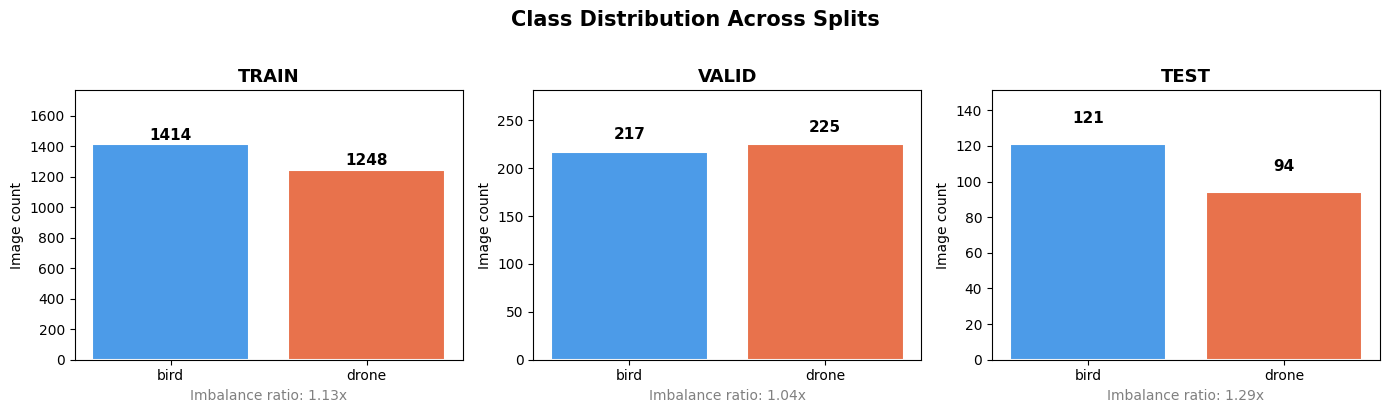

Saved: class_distribution.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#4C9BE8', '#E8724C']

for ax, split in zip(axes, SPLITS):
    vals = [counts[split][c] for c in CLASSES]
    bars = ax.bar(CLASSES, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(split, fontsize=13, fontweight='bold')
    ax.set_ylabel('Image count')
    ax.set_ylim(0, max(vals) * 1.25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
    # Imbalance ratio
    ratio = max(vals) / min(vals) if min(vals) > 0 else float('inf')
    ax.set_xlabel(f'Imbalance ratio: {ratio:.2f}x', fontsize=10, color='gray')

plt.suptitle('Class Distribution Across Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

## 1.3 — Visualize Sample Images

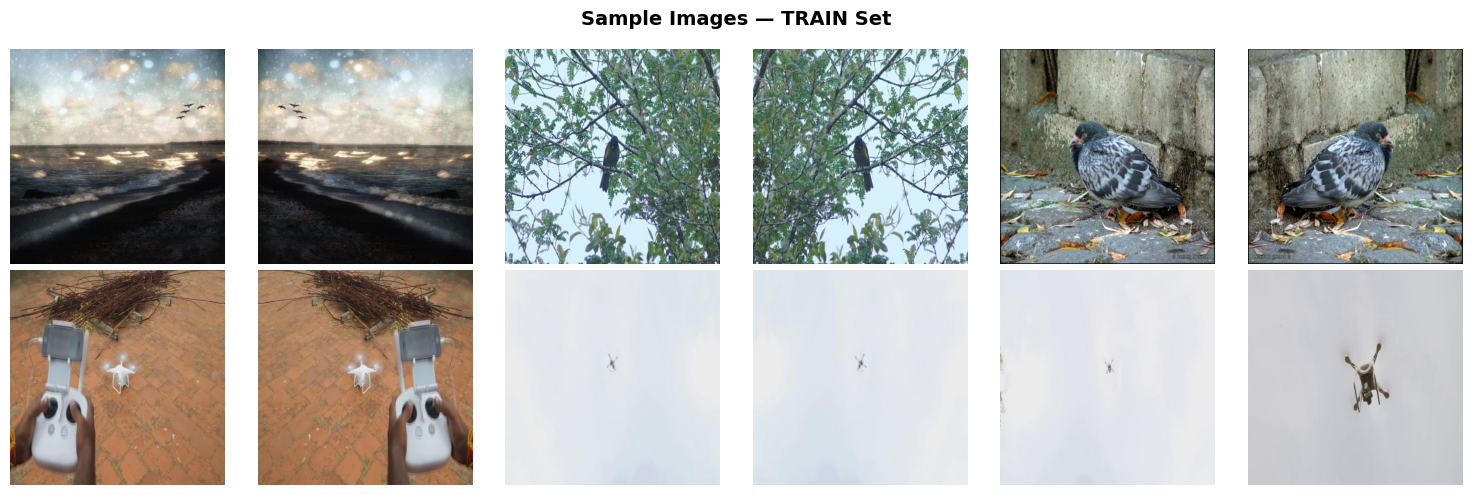

In [4]:
def show_samples(split='TRAIN', n_per_class=6):
    fig, axes = plt.subplots(len(CLASSES), n_per_class, figsize=(n_per_class*2.5, len(CLASSES)*2.5))
    for row, cls in enumerate(CLASSES):
        folder = DATASET_ROOT / split / cls
        images = list(folder.glob('*.jpg')) + list(folder.glob('*.png')) + list(folder.glob('*.jpeg'))
        images = images[:n_per_class]
        for col, img_path in enumerate(images):
            img = Image.open(img_path).convert('RGB')
            axes[row][col].imshow(img)
            axes[row][col].axis('off')
            if col == 0:
                axes[row][col].set_ylabel(cls.upper(), fontsize=12, fontweight='bold',
                                          color=colors[row], rotation=90, labelpad=10)
    plt.suptitle(f'Sample Images — {split} Set', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'samples_{split.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples('TRAIN', n_per_class=6)

## 1.4 — Image Size Distribution

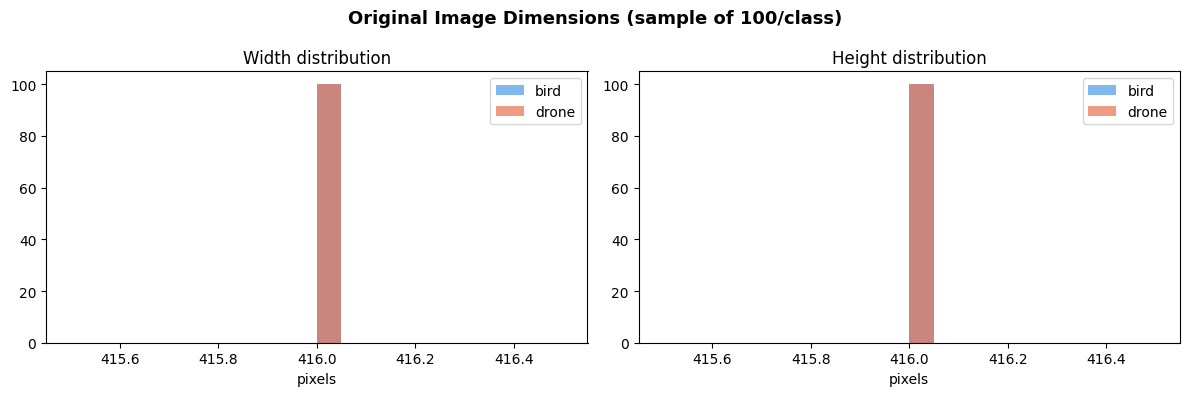

In [5]:
widths, heights, labels_list = [], [], []
for cls in CLASSES:
    folder = DATASET_ROOT / 'TRAIN' / cls
    imgs = list(folder.glob('*.jpg'))[:100]  # sample 100 per class
    for p in imgs:
        w, h = Image.open(p).size
        widths.append(w); heights.append(h); labels_list.append(cls)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cls, color in zip(CLASSES, colors):
    mask = [l == cls for l in labels_list]
    axes[0].hist([w for w, m in zip(widths, mask) if m], bins=20, alpha=0.7, color=color, label=cls)
    axes[1].hist([h for h, m in zip(heights, mask) if m], bins=20, alpha=0.7, color=color, label=cls)

axes[0].set_title('Width distribution'); axes[0].legend(); axes[0].set_xlabel('pixels')
axes[1].set_title('Height distribution'); axes[1].legend(); axes[1].set_xlabel('pixels')
plt.suptitle('Original Image Dimensions (sample of 100/class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.1 — Augmentation Preview

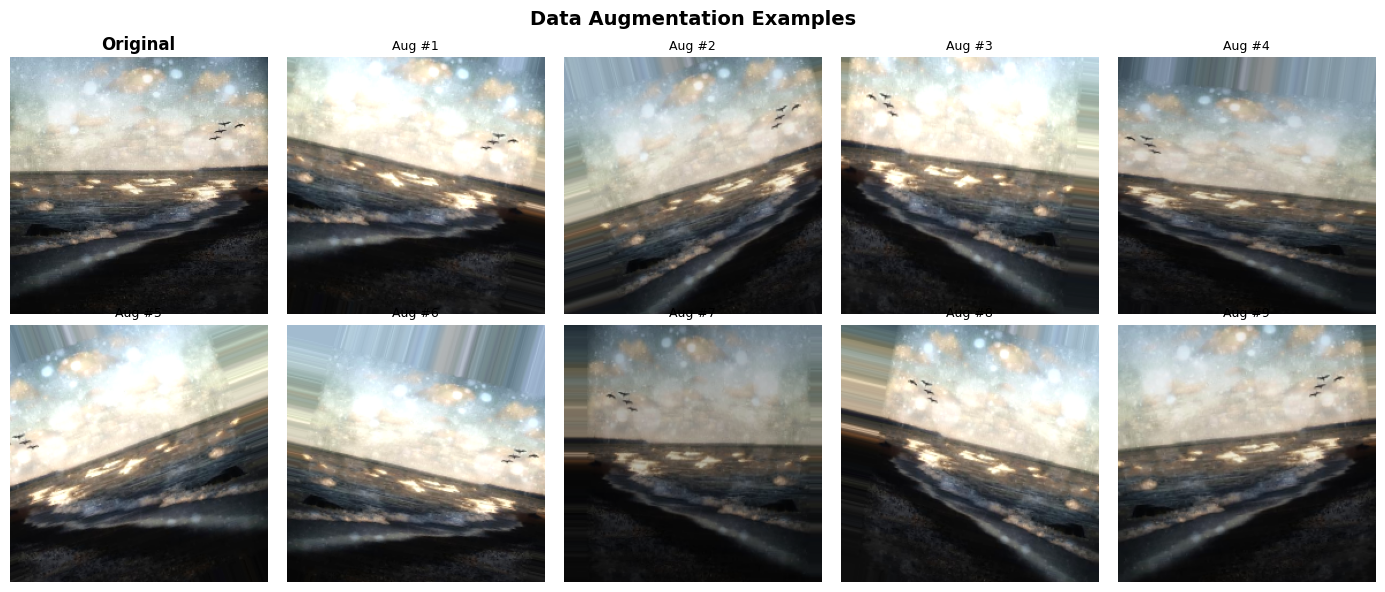

Phase 1 & 2 complete!


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Pick one sample image to demo augmentation
sample_folder = DATASET_ROOT / 'TRAIN' / 'bird'
sample_path = list(sample_folder.glob('*.jpg'))[0]
sample_img = tf.keras.utils.load_img(sample_path, target_size=IMG_SIZE)
sample_arr = tf.keras.utils.img_to_array(sample_img)
sample_arr = sample_arr.reshape((1,) + sample_arr.shape)

aug_gen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    shear_range=0.1,
    fill_mode='nearest'
)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes[0][0].imshow(sample_img); axes[0][0].set_title('Original', fontweight='bold'); axes[0][0].axis('off')

gen = aug_gen.flow(sample_arr, batch_size=1)
for i, ax in enumerate(axes.flatten()[1:]):
    batch = next(gen)
    ax.imshow(batch[0].astype('uint8'))
    ax.set_title(f'Aug #{i+1}', fontsize=9)
    ax.axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Phase 1 & 2 complete!')